In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('infection_wait_times.csv')

In [2]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [3]:
#Add day of week feature
df["Day of Week"] = df["Date"].dt.day_name()

# Perform EDA


## Day of Week vs. Persons Waiting

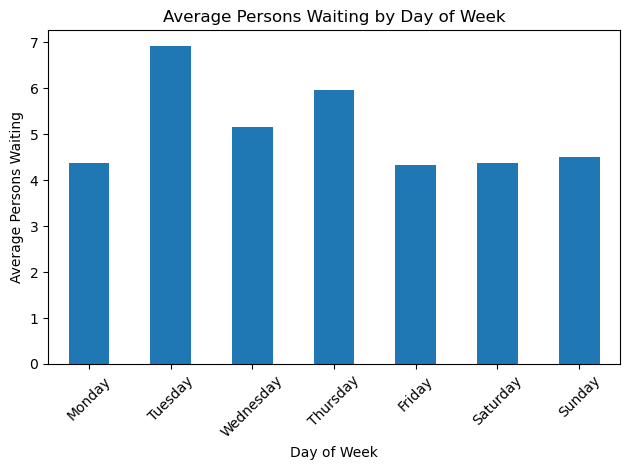

In [4]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

average_waiting = (
    df.groupby("Day of Week")["Average Persons Waiting"]
    .mean()
    .reindex(day_order)
)

average_waiting.plot(kind="bar")

plt.xlabel("Day of Week")
plt.ylabel("Average Persons Waiting")
plt.title("Average Persons Waiting by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
day_dummies = pd.get_dummies(
    df["Day of Week"],
    dtype=int
)

correlations = day_dummies.join(
    df["Average Persons Waiting"]
).corr()["Average Persons Waiting"].drop(
    "Average Persons Waiting"
)

print(correlations)

Friday      -0.065262
Monday      -0.061758
Saturday    -0.062113
Sunday      -0.049938
Thursday     0.076644
Tuesday      0.157531
Wednesday    0.005982
Name: Average Persons Waiting, dtype: float64


## COVID vs. Persons Waiting

In [6]:
correlation = df[
    ["COVID Cases", "Average Persons Waiting"]
].corr().loc["COVID Cases", "Average Persons Waiting"]

print(correlation)

0.1554717320349855


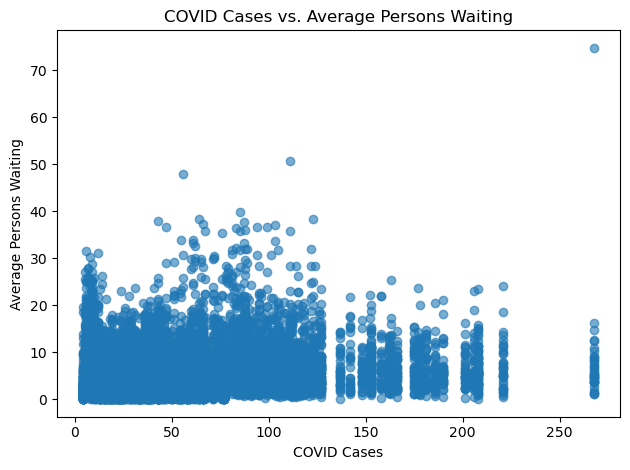

In [7]:
plot_data = df[
    ["COVID Cases", "Average Persons Waiting"]
].dropna()

plt.scatter(
    plot_data["COVID Cases"],
    plot_data["Average Persons Waiting"],
    alpha=0.6
)

plt.xlabel("COVID Cases")
plt.ylabel("Average Persons Waiting")
plt.title("COVID Cases vs. Average Persons Waiting")
plt.tight_layout()
plt.show()

## RSV vs. Persons Waiting

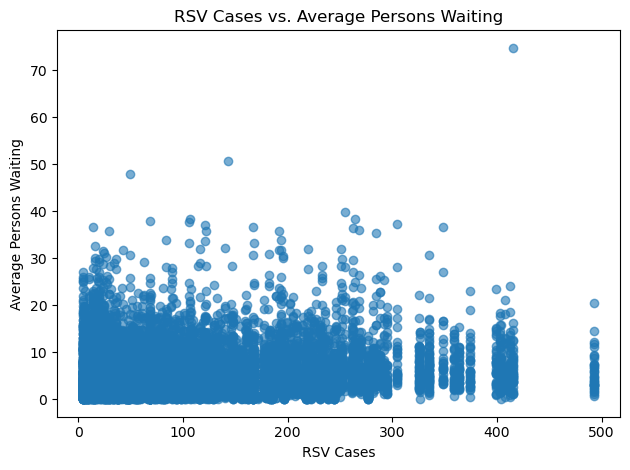

In [8]:
plot_data = df[
    ["RSV Cases", "Average Persons Waiting"]
].dropna()

plt.scatter(
    plot_data["RSV Cases"],
    plot_data["Average Persons Waiting"],
    alpha=0.6
)

plt.xlabel("RSV Cases")
plt.ylabel("Average Persons Waiting")
plt.title("RSV Cases vs. Average Persons Waiting")
plt.tight_layout()
plt.show()

In [9]:
rsv_correlation = df[
    ["RSV Cases", "Average Persons Waiting"]
].dropna().corr().loc[
    "RSV Cases", "Average Persons Waiting"
]

print(rsv_correlation)

0.09598237569017197


## Influenza vs. Persons Waiting

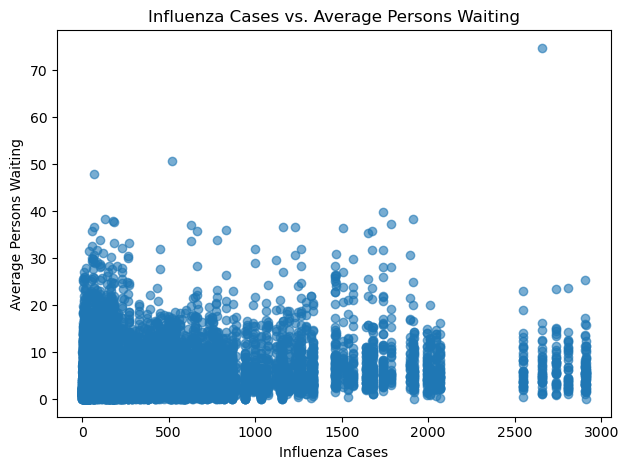

0.1256465486735807


In [10]:
plot_data = df[
    ["Influenza Cases", "Average Persons Waiting"]
].dropna()

plt.scatter(
    plot_data["Influenza Cases"],
    plot_data["Average Persons Waiting"],
    alpha=0.6
)

plt.xlabel("Influenza Cases")
plt.ylabel("Average Persons Waiting")
plt.title("Influenza Cases vs. Average Persons Waiting")
plt.tight_layout()
plt.show()

influenza_correlation = plot_data.corr().loc[
    "Influenza Cases", "Average Persons Waiting"
]

print(influenza_correlation)

## Combining Averages for Infectious Diseases

In [11]:
df['Combined Cases'] = df['COVID Cases'] + df['RSV Cases'] + df['Influenza Cases']

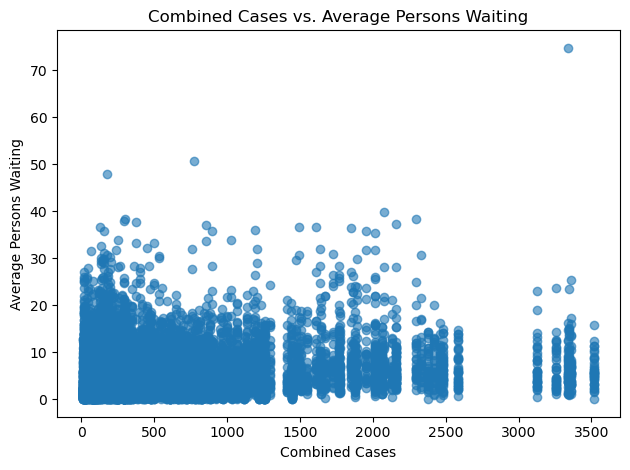

0.12783498295525145


In [12]:
plot_data = df[
    ["Combined Cases", "Average Persons Waiting"]
].dropna()

plt.scatter(
    plot_data["Combined Cases"],
    plot_data["Average Persons Waiting"],
    alpha=0.6
)

plt.xlabel("Combined Cases")
plt.ylabel("Average Persons Waiting")
plt.title("Combined Cases vs. Average Persons Waiting")
plt.tight_layout()
plt.show()

combined_correlation = df[
    ["Combined Cases", "Average Persons Waiting"]
].dropna().corr().loc[
    "Combined Cases", "Average Persons Waiting"
]

print(combined_correlation)

## Hospital Based Waiting Times



In [13]:
plot_data = df[
    ["Hospital Name", "Combined Cases", "Average Persons Waiting"]
].dropna()

hospitals = plot_data["Hospital Name"].unique()

fig, axes = plt.subplots(
    len(hospitals), 1,
    figsize=(8, 4 * len(hospitals)),
    squeeze=False
)

for ax, hospital in zip(axes.ravel(), hospitals):
    hospital_data = plot_data[
        plot_data["Hospital Name"] == hospital
    ]

    ax.scatter(
        hospital_data["Combined Cases"],
        hospital_data["Average Persons Waiting"],
        alpha=0.6
    )

    ax.set_title(hospital)
    ax.set_xlabel("Combined Cases")
    ax.set_ylabel("Average Persons Waiting")

plt.tight_layout()
plt.show()

## LOESS Visualisation
T



In [14]:
from statsmodels.nonparametric.smoothers_lowess import lowess

plot_data = df[
    ["Hospital Name", "Combined Cases", "Average Persons Waiting"]
].dropna()

hospitals = plot_data["Hospital Name"].unique()

fig, axes = plt.subplots(
    len(hospitals),
    1,
    figsize=(8, 4 * len(hospitals)),
    squeeze=False
)

for ax, hospital in zip(axes.ravel(), hospitals):
    hospital_data = plot_data[
        plot_data["Hospital Name"] == hospital
    ].sort_values("Combined Cases")

    lowess_result = lowess(
        hospital_data["Average Persons Waiting"],
        hospital_data["Combined Cases"],
        frac=0.6
    )

    ax.scatter(
        hospital_data["Combined Cases"],
        hospital_data["Average Persons Waiting"],
        alpha=0.4,
        label="Observed data"
    )

    ax.plot(
        lowess_result[:, 0],
        lowess_result[:, 1],
        color="red",
        linewidth=2,
        label="LOWESS trend"
    )

    ax.set_title(hospital)
    ax.set_xlabel("Combined Cases")
    ax.set_ylabel("Average Persons Waiting")
    ax.legend()

plt.tight_layout()
plt.show()

## Conclusion
Based on initial EDA, the linear relationship between Day of Week or Infectious cases is low. Even performing LOESS visualisation supports this